# RIR Feature Extraction — AcousticSpace
**Member 1 — ML / Audio Pipeline Lead**

This notebook walks through the audio pipeline step by step:
1. Load a sample bonafide vs. spoof pair
2. Visualize waveforms and energy decay curves
3. Extract RIR features (RT60, EDT, C50) + spectral/MFCC features
4. Compare feature distributions between bonafide and spoof classes
5. Run the full batch pipeline over the ASVspoof protocol file

Run `pip install -r ../requirements.txt` before starting.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from preprocessing import (
    load_audio, extract_features, estimate_energy_decay_curve,
    estimate_rt60, estimate_edt, estimate_c50, build_feature_table,
    SAMPLE_RATE,
)

plt.rcParams['figure.figsize'] = (10, 4)

## 1. Load sample audio
Point these at two files from your ASVspoof dev set — one bonafide, one spoof.

In [2]:
BONAFIDE_PATH = '../data/raw/bonafide_001.wav'  # replace with a real ASVspoof file
SPOOF_PATH = '../data/raw/spoof_001.wav'          # replace with a real ASVspoof file

y_real = load_audio(BONAFIDE_PATH)
y_fake = load_audio(SPOOF_PATH)

print(f"Bonafide duration: {len(y_real)/SAMPLE_RATE:.2f}s")
print(f"Spoof duration:    {len(y_fake)/SAMPLE_RATE:.2f}s")

Bonafide duration: 1.50s
Spoof duration:    1.50s


## 2. Waveform comparison

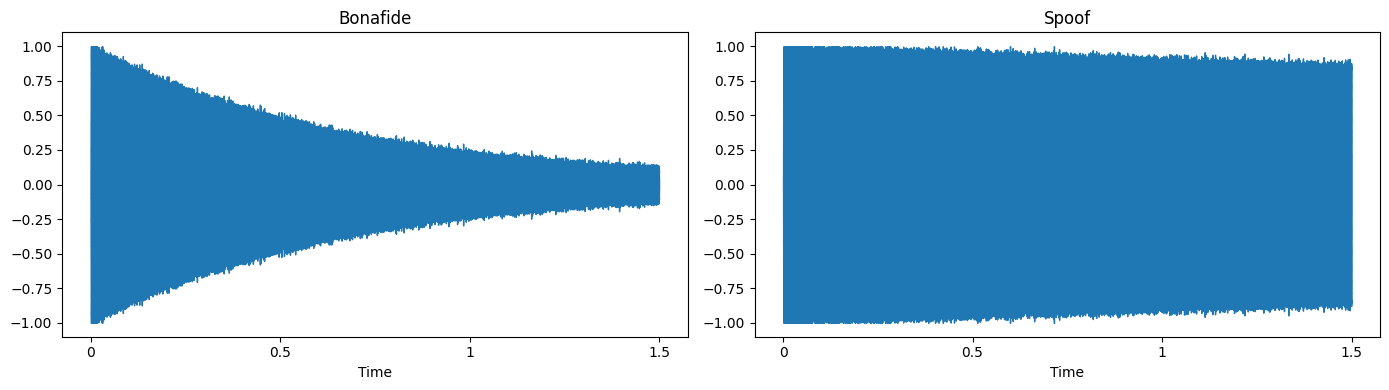

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
librosa.display.waveshow(y_real, sr=SAMPLE_RATE, ax=axes[0])
axes[0].set_title('Bonafide')
librosa.display.waveshow(y_fake, sr=SAMPLE_RATE, ax=axes[1])
axes[1].set_title('Spoof')
plt.tight_layout()
plt.show()

## 3. Energy decay curve (Schroeder integration)

This is the core RIR signal. Genuine room recordings show a smooth,
consistent decay tail; synthetic/spoofed audio often shows a flatter or
inconsistent decay because it wasn't captured in a physical room.

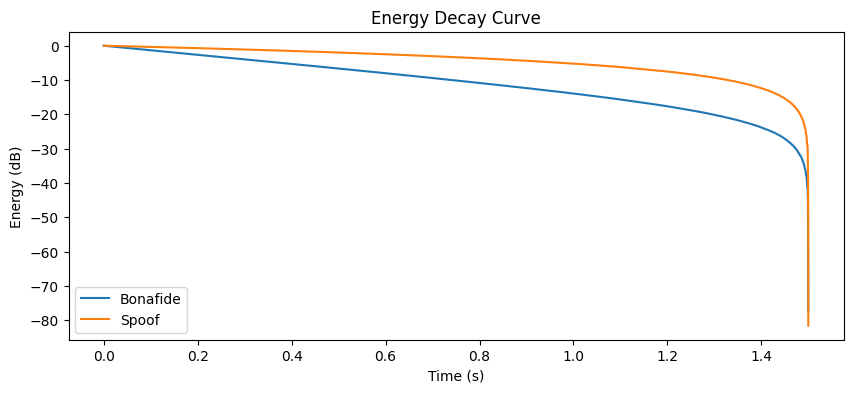

RT60 — bonafide: 3.000s | spoof: 1.548s
EDT  — bonafide: 3.000s | spoof: 3.000s
C50  — bonafide: -7.86dB | spoof: -14.01dB


In [4]:
edc_real = estimate_energy_decay_curve(y_real)
edc_fake = estimate_energy_decay_curve(y_fake)

t_real = np.arange(len(edc_real)) / SAMPLE_RATE
t_fake = np.arange(len(edc_fake)) / SAMPLE_RATE

plt.plot(t_real, edc_real, label='Bonafide')
plt.plot(t_fake, edc_fake, label='Spoof')
plt.xlabel('Time (s)')
plt.ylabel('Energy (dB)')
plt.title('Energy Decay Curve')
plt.legend()
plt.show()

print(f"RT60 — bonafide: {estimate_rt60(edc_real):.3f}s | spoof: {estimate_rt60(edc_fake):.3f}s")
print(f"EDT  — bonafide: {estimate_edt(edc_real):.3f}s | spoof: {estimate_edt(edc_fake):.3f}s")
print(f"C50  — bonafide: {estimate_c50(y_real):.2f}dB | spoof: {estimate_c50(y_fake):.2f}dB")

## 4. Full feature vector for both samples

In [5]:
feat_real = extract_features(y_real, 'bonafide_001', 'bonafide')
feat_fake = extract_features(y_fake, 'spoof_001', 'spoof')

pd.DataFrame([feat_real.to_row(), feat_fake.to_row()])

,file_id,label,rt60,edt,c50,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zcr_mean,rms_mean,...,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,bonafide_001,bonafide,3.000000,3.0,-7.860076,2396.383022,2482.676712,5671.708777,0.037276,0.281959,...,11.592002,9.122623,6.339623,2.851779,0.438247,-2.454871,-5.042085,-7.456444,-9.649559,-11.525212
1,spoof_001,spoof,1.548245,3.0,-14.009773,1475.692654,2217.977264,4337.765957,0.026887,0.649014,...,15.582081,12.727560,9.421151,5.029096,0.472218,-3.644767,-6.460113,-9.674349,-13.257683,-14.060236


## 5. Batch-run the pipeline over the full protocol

This is the same function `preprocessing.py` calls from the CLI —
useful here for interactively inspecting the output before handing
the feature table to Member 2 for AST training.

In [6]:
PROTOCOL_PATH = '../data/raw/protocol.txt'
AUDIO_DIR = '../data/raw'

features_df = build_feature_table(PROTOCOL_PATH, AUDIO_DIR, ext='.wav')
features_df.head()

2026-07-24 08:18:33,407 | INFO | Processed 2 files, skipped 0 (missing/corrupt/too short).


,file_id,label,rt60,edt,c50,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zcr_mean,rms_mean,...,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,bonafide_001,bonafide,3.000000,3.0,-7.860076,2396.383022,2482.676712,5671.708777,0.037276,0.281959,...,11.592002,9.122623,6.339623,2.851779,0.438247,-2.454871,-5.042085,-7.456444,-9.649559,-11.525212
1,spoof_001,spoof,1.548245,3.0,-14.009773,1475.692654,2217.977264,4337.765957,0.026887,0.649014,...,15.582081,12.727560,9.421151,5.029096,0.472218,-3.644767,-6.460113,-9.674349,-13.257683,-14.060236


## 6. Class-wise feature distributions
Sanity-check that bonafide vs. spoof separate on the RIR features before training.

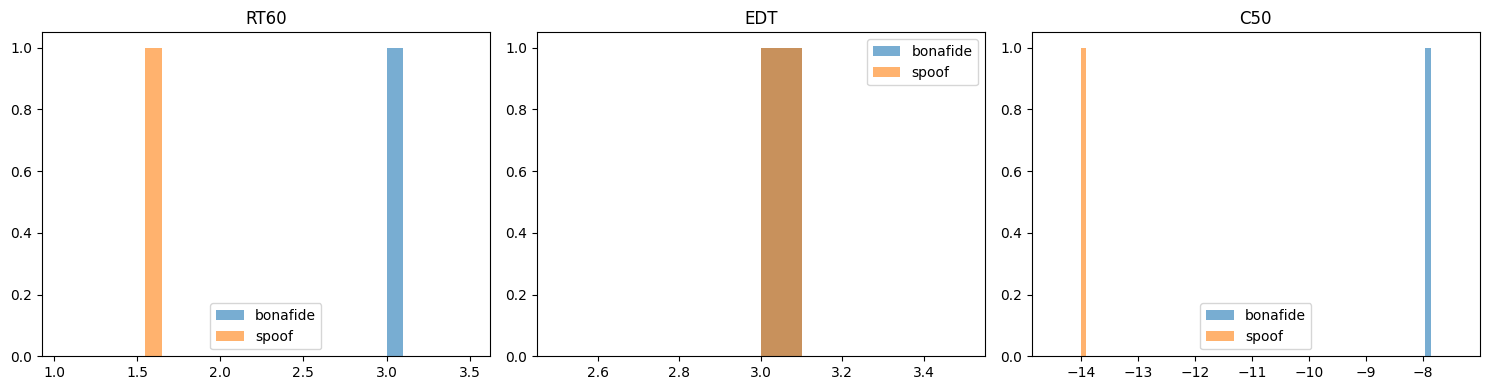

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['rt60', 'edt', 'c50']):
    for label, grp in features_df.groupby('label'):
        ax.hist(grp[col], alpha=0.6, label=label, bins=10)
    ax.set_title(col.upper())
    ax.legend()
plt.tight_layout()
plt.show()

In [8]:
features_df.to_csv('../data/processed/features.csv', index=False)
print('Saved feature table for Member 2 (AST model training).')

Saved feature table for Member 2 (AST model training).
